In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Set plotting styles for EDA
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [28]:
# ==========================================
# Stage 1 - Load & Clean Columns
# ==========================================
print("--- Stage 1: Loading Dataset ---")
# Load the supply chain dataset
supply_df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

# Format column names uniformly to avoid syntax/key spacing issues
supply_df.columns = supply_df.columns.str.lower().str.replace(' ', '_').str.replace('(', '', regex=False).str.replace(')', '', regex=False)

print(f"Dataset Dimensions: {supply_df.shape[0]} rows, {supply_df.shape[1]} columns\n")

--- Stage 1: Loading Dataset ---
Dataset Dimensions: 180519 rows, 53 columns



Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


--- Stage 2: Running Exploratory Data Analysis ---
Columns with missing values:
                     Missing Count  Percentage (%)
customer_lname                   8        0.004432
customer_zipcode                 3        0.001662
order_zipcode               155679       86.239676
product_description         180519      100.000000 

Target Distribution ('late_delivery_risk'):
late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


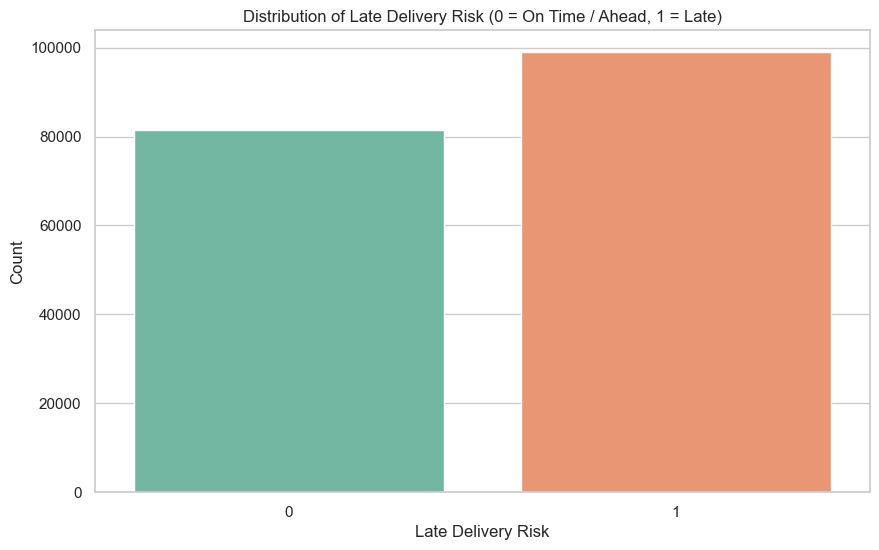


Late Delivery Rate across different Shipping Modes:
shipping_mode
First Class       0.953225
Second Class      0.766328
Same Day          0.457430
Standard Class    0.380717
Name: late_delivery_risk, dtype: float64


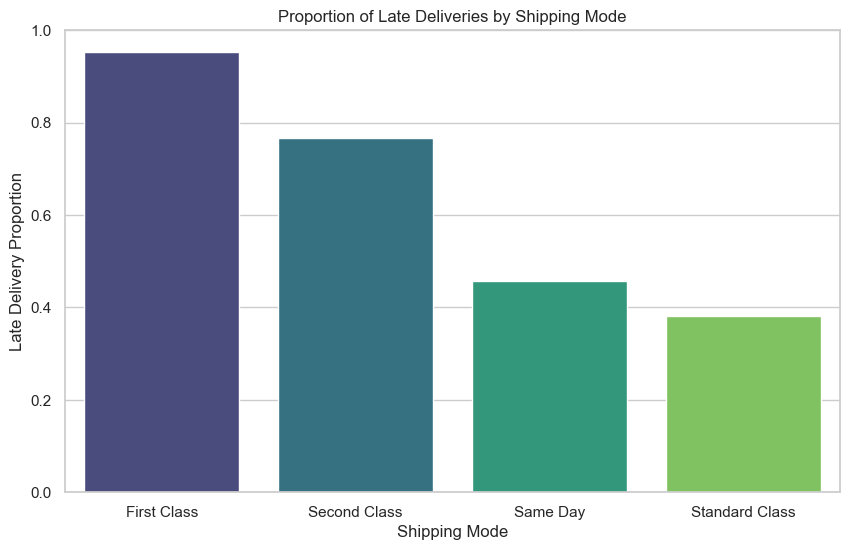

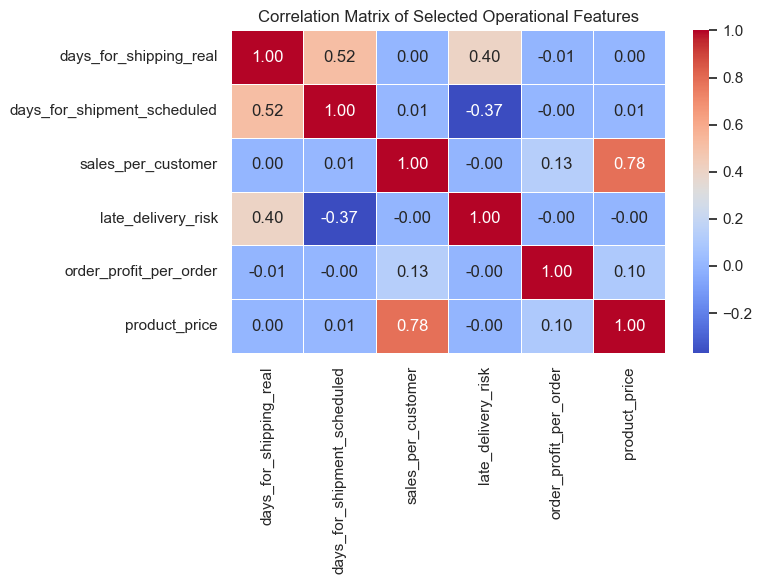

In [30]:
# ==========================================
# Stage 2 - Exploratory Data Analysis (EDA)
# ==========================================
print("--- Stage 2: Running Exploratory Data Analysis ---")

# 1. Inspect Basic Missing Value Structure
missing_values = supply_df.isnull().sum()
missing_pct = (missing_values / len(supply_df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_pct})
print("Columns with missing values:")
print(missing_report[missing_report['Missing Count'] > 0], "\n")

# 2. Analyze Target Variable Class Distribution
target_col = 'late_delivery_risk'
if target_col in supply_df.columns:
    print("Target Distribution ('late_delivery_risk'):")
    print(supply_df[target_col].value_counts(normalize=True))
    
    # Generate distribution plot
    plt.figure()
    sns.countplot(data=supply_df, x=target_col, hue=target_col, palette='Set2', legend=False)
    plt.title('Distribution of Late Delivery Risk (0 = On Time / Ahead, 1 = Late)')
    plt.xlabel('Late Delivery Risk')
    plt.ylabel('Count')
    plt.show()

# 3. Analyze Risk Categorized by Shipping Mode
if 'shipping_mode' in supply_df.columns and target_col in supply_df.columns:
    print("\nLate Delivery Rate across different Shipping Modes:")
    mode_risk = supply_df.groupby('shipping_mode')[target_col].mean().sort_values(ascending=False)
    print(mode_risk)
    
    plt.figure()
    sns.barplot(x=mode_risk.index, y=mode_risk.values, hue=mode_risk.index, palette='viridis', legend=False)
    plt.title('Proportion of Late Deliveries by Shipping Mode')
    plt.xlabel('Shipping Mode')
    plt.ylabel('Late Delivery Proportion')
    plt.ylim(0, 1.0)
    plt.show()

# 4. Correlation Analysis to Check for Overlapping Leaks
# Select numerical variables to inspect linear alignment
numerical_cols = supply_df.select_dtypes(include=[np.number]).columns.tolist()
# Filter down to operational/financial metrics for a clean correlation heatmap
sample_numerical = [c for c in numerical_cols if c in [
    'days_for_shipping_real', 'days_for_shipment_scheduled', 
    'order_profit_per_order', 'sales_per_customer', 'product_price', 'late_delivery_risk'
]]

if len(sample_numerical) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(supply_df[sample_numerical].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix of Selected Operational Features')
    plt.tight_layout()
    plt.show()

In [32]:
# ==========================================
# Stage 3 - Drop Direct Leaks & IDs
# ==========================================
print("\n--- Stage 3: Feature Filtering & Leakage Remediation ---")

# Data Leakage Drop List:
# We drop 'days_for_shipping_real' because knowing actual shipping days deterministically reveals if it was late.
# We also drop post-sale variables calculated after order completion.
leaky_and_id_cols = [
    'days_for_shipping_real',       # Ultimate target leak
    'delivery_status',              # Text target proxy
    'order_profit_per_order',       # Post-fulfillment variable
    'benefit_per_order',            # Post-fulfillment variable
    'order_item_profit_ratio',      # Post-fulfillment variable
    'sales_per_customer',           # Post-fulfillment variable
    'sales',                        # Post-fulfillment financial data
    'order_item_total',             # Post-fulfillment financial data
    'order_id', 'customer_id',      # High cardinality sequence keys
    'order_item_id', 'product_card_id',
    'customer_email', 'customer_password', 
    'product_description', 'product_image'
]

existing_drop = [c for c in leaky_and_id_cols if c in supply_df.columns]
supply_df = supply_df.drop(columns=existing_drop)
print(f"Dropped {len(existing_drop)} leaking/unnecessary feature columns.")


--- Stage 3: Feature Filtering & Leakage Remediation ---
Dropped 16 leaking/unnecessary feature columns.


In [34]:
# ==========================================
# Stage 4 - Feature Engineering
# ==========================================
print("\n--- Stage 4: Feature Engineering ---")

# Safe conversion of date profiles known at point-of-sale
supply_df['order_date_dateorders'] = pd.to_datetime(supply_df['order_date_dateorders'])

supply_df['order_month'] = supply_df['order_date_dateorders'].dt.month
supply_df['order_quarter'] = supply_df['order_date_dateorders'].dt.quarter
supply_df['is_weekend'] = (supply_df['order_date_dateorders'].dt.dayofweek >= 5).astype(int)

# Engineer behavioral order frequency by location block
supply_df['customer_frequency'] = supply_df.groupby('customer_zipcode')['customer_zipcode'].transform('count')
supply_df['customer_frequency'] = supply_df['customer_frequency'].fillna(1)

# Drop datetime tracking representations to avoid structural model processing errors
supply_df = supply_df.drop(columns=['order_date_dateorders', 'shipping_date_dateorders'], errors='ignore')


--- Stage 4: Feature Engineering ---


In [36]:
# ==========================================
# Stage 5 - Modeling Pipeline Setup
# ==========================================
print("\n--- Stage 5: Constructing Pipeline Architecture ---")

X = supply_df.drop(columns=[target_col])
y = supply_df[target_col]

# Define robust numerical & categorical feature inclusions
num_features = [
    'days_for_shipment_scheduled', 'customer_frequency', 
    'order_month', 'order_quarter', 'is_weekend', 
    'order_item_discount', 'order_item_quantity', 'product_price'
]
cat_features = ['market', 'shipping_mode', 'customer_segment', 'category_name', 'order_region']

# Isolate feature landscape
X = X[num_features + cat_features]

# Stratified Train-Test Split (preserves target balance across both subsets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build numerical preprocessor sub-pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Build categorical preprocessor sub-pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Merge preprocessors via ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Complete deployment pipeline leveraging a Tree-based Random Forest Classifier
optimized_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])


--- Stage 5: Constructing Pipeline Architecture ---


In [38]:
# ==========================================
# Stage 6 - Model Training & Evaluation
# ==========================================
print("\n--- Stage 6: Training and Evaluating Model ---")
optimized_pipeline.fit(X_train, y_train)

# Predictions and probabilities
predictions = optimized_pipeline.predict(X_test)
probabilities = optimized_pipeline.predict_proba(X_test)[:, 1]

print("\n=== FINAL CLEANED MODEL PERFORMANCE ===")
print(f"Accuracy Score: {accuracy_score(y_test, predictions):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, probabilities):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, predictions))


--- Stage 6: Training and Evaluating Model ---

=== FINAL CLEANED MODEL PERFORMANCE ===
Accuracy Score: 0.7004
ROC-AUC Score:  0.7421

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.87      0.72     16308
           1       0.84      0.56      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.74      0.70      0.70     36104

